In [1]:
import utils
import keras
import numpy as np
import matplotlib.pyplot as plt

2026-02-22 13:51:59.778651: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-22 13:52:00.425918: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-22 13:52:11.378684: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
columns = ("model", "lighting", "year")
other = 'Other car'

In [3]:
(train_x, train_y), (test_x, test_y) = utils.read_stratified_data(columns=columns, strata_threshold=38)

/mnt/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett/275815406_Andrew-Crowley-1_trans_NvBQzQNjv4BqJgZjG4XE8BZGTSy9SLp5TPzOL_bEerq8T.jpg /data/upload/3/bb413a1b-275815406_Andrew-Crowley-1_trans_NvBQzQNjv4BqJgZjG4XE8BZGTSy9SLp5TPzOL_bEerq8T.jpg
/mnt/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett/kisspng-2018-tesla-model-s-tesla-motors-car-ele_fLj30kA.2230115115224762368998.png /data/upload/3/5e846c95-kisspng-2018-tesla-model-s-tesla-motors-car-ele_fLj30kA.2230115115224762368998.png
/mnt/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett/black-tesla-model-x-carbon-fiber-spoiler-mx22-forged-aftermarket-wheel_tCrLNla.jpg /data/upload/3/e82f4a47-black-tesla-model-x-carbon-fiber-spoiler-mx22-forged-aftermarket-wheel_tCrLNla.jpg
/mnt/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett/Edmu_EmY1CYe.-2020-Tesla-Model-Ywire-38540856-1611748943-973_634x3962-1280x720.jpg /data/uploa

In [ ]:

vt = np.vectorize(lambda x: 1 if x else 0)

train_y_gate1 = train_y["model"] == other
train_y_gate1 = vt(train_y_gate1)
test_y_gate1 = test_y["model"] == other
test_y_gate1 = vt(test_y_gate1)

input_shape = train_x[0].shape
num_classes = 1


def model_to_int(model):
    dict = {'S': 0, '3': 1, 'X':2, 'Y': 3}
    return dict[model]


train_y_gate2 = train_y["model"][train_y["model"] != other]
train_y_gate2 = np.vectorize(model_to_int)(train_y_gate2)

train_x_gate2 = train_x[train_y["model"] != other]

test_y_gate2 = test_y["model"][test_y["model"] != other]
test_y_gate2 = np.vectorize(model_to_int)(test_y_gate2)

test_x_gate2 = test_x[test_y["model"] != other]

input_shape = train_x[0].shape

In [5]:
i = 0

1


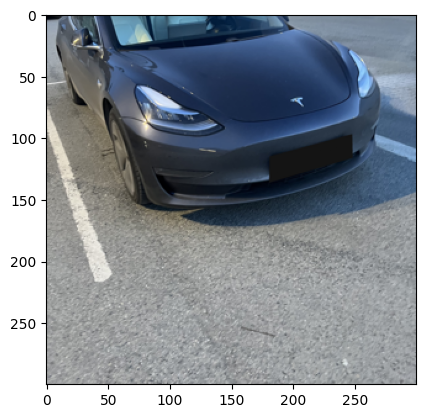

In [6]:
print(train_y_gate2[i])
plt.imshow(train_x_gate2[i])
i += 1

In [7]:
def get_feature_extractor(input_shape):
    inputs = keras.Input(shape=input_shape)
    x = keras.layers.Conv2D(64, (3, 3), activation="relu")(inputs)
    x = keras.layers.MaxPooling2D((2, 2))(x)
    x = keras.layers.Conv2D(64, (3, 3), activation="relu")(x)
    x = keras.layers.MaxPooling2D((2, 2))(x)
    x = keras.layers.Conv2D(64, (3, 3), activation="relu")(x)
    x = keras.layers.MaxPooling2D((2, 2))(x)
    x = keras.layers.Conv2D(64, (3, 3), activation="relu")(x)
    x = keras.layers.MaxPooling2D((2, 2))(x)
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dropout(0.4)(x)
    return keras.Model(inputs, x, name="extractor")

feature_extractor = get_feature_extractor(input_shape=input_shape)

input_gate1 = keras.Input(shape=input_shape)
x = feature_extractor(input_gate1)
outputs_gate1 = keras.layers.Dense(1, activation="sigmoid")(x)
model_a = keras.Model(input_gate1, outputs_gate1)

input_gate2 = input_gate1
x = feature_extractor(input_gate2)
output_gate2 = keras.layers.Dense(4, activation="softmax")(x)
model_b = keras.Model(input_gate2, output_gate2)

model_a.compile(
    optimizer=keras.optimizers.Adam(3e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
model_b.compile(
    optimizer=keras.optimizers.Adam(3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model_a.fit(train_x, train_y_gate1, epochs=10, batch_size=16)
print(model_a.evaluate(test_x, test_y_gate1))
model_b.fit(train_x_gate2, train_y_gate2, epochs=10, batch_size=16)



I0000 00:00:1771764779.730009    3783 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9569 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:01:00.0, compute capability: 8.6


Epoch 1/10


2026-02-22 13:53:08.467606: I external/local_xla/xla/service/service.cc:163] XLA service 0x7df698004f80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-22 13:53:08.467641: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3080, Compute Capability 8.6
2026-02-22 13:53:08.622250: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-22 13:53:09.143757: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90300


  7/232 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.4509 - loss: 0.7026

I0000 00:00:1771764794.220319    5521 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


232/232 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.7050 - loss: 0.5748
Epoch 2/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.7815 - loss: 0.4795
Epoch 3/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8066 - loss: 0.4317
Epoch 4/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8209 - loss: 0.4024
Epoch 5/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8420 - loss: 0.3692
Epoch 6/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8585 - loss: 0.3193
Epoch 7/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8760 - loss: 0.2950
Epoch 8/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8871 - loss: 0.2646
Epoch 9/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9106 - loss: 0.2249
Epoch 10/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9195 - loss: 0.1973
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.8468 - loss: 0.4251
[0.42512986063957214, 0.8467614650726318]
Epoch 1/10
123/123 ━━━━

In [8]:

print(model_a.evaluate(test_x, test_y_gate1))
print(model_b.evaluate(test_x_gate2, test_y_gate2))

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8294 - loss: 0.7610
[0.7610183358192444, 0.829383909702301]


2026-02-22 13:54:50.978565: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_124', 8 bytes spill stores, 8 bytes spill loads

2026-02-22 13:54:51.094164: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_124', 8 bytes spill stores, 8 bytes spill loads



11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - accuracy: 0.5569 - loss: 1.7980
[1.7979670763015747, 0.5569230914115906]


In [9]:
i = 0

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[[0.01740142]]


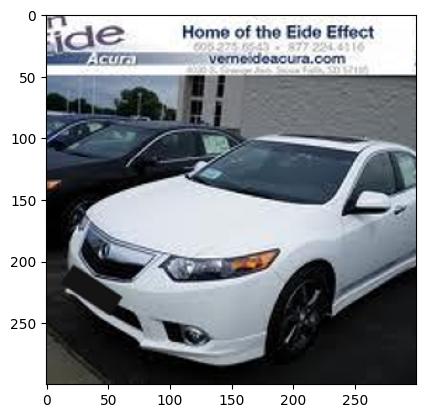

In [37]:
error = False
while(not error):
    pred = model_a.predict(np.expand_dims(test_x[i], axis=0))
    error = test_y_gate1[i] > 0.5 and pred < 0.5
    i += 1
print(pred)
plt.imshow(test_x[i-1])